<a href="https://colab.research.google.com/github/PVC2020/Agriculture-Crop-Production-In-India/blob/main/Crop_analysis_and_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CROP RECOMMENDATION USING WEATHER AND SOIL CONTENT



In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df_crop=pd.read_csv('Crop_recommendation.csv')
print (df_crop.head())

print(df_crop.info())
print(display(df_crop[['humidity','temperature','ph','rainfall']].describe()))


    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None


,humidity,temperature,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,71.481779,25.616244,6.469480,103.463655
std,22.263812,5.063749,0.773938,54.958389
min,14.258040,8.825675,3.504752,20.211267
25%,60.261953,22.769375,5.971693,64.551686
50%,80.473146,25.598693,6.425045,94.867624
75%,89.948771,28.561654,6.923643,124.267508
max,99.981876,43.675493,9.935091,298.560117


None


In [18]:
print(df_crop.isnull().sum()) #verifica se tem valores nulos no df
print("quantidade total de valores duplicados = ", df_crop.duplicated().sum()) #verifica se tem valores duplicados no df

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
quantidade total de valores duplicados =  0


### 1. Análise Quantitativa e Qualitativa dos Dados
Nesta etapa, geramos um resumo descritivo de todas as colunas numéricas para entender sua amplitude, média e desvio padrão, além de analisar a distribuição da nossa coluna de destino (`label`).

In [19]:
# Resumo estatístico detalhado de todas as variáveis numéricas
print("--- Estatísticas Descritivas ---")
display(df_crop.describe())

# Verificação da distribuição da variável alvo 'label'
print("\n--- Distribuição das Classes (Label) ---")
display(df_crop['label'].value_counts())

--- Estatísticas Descritivas ---


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



--- Distribuição das Classes (Label) ---


,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


### 2. Análise Visual de Dados Faltantes
Usaremos um mapa de calor para verificar visualmente se existe algum padrão ou concentração de dados nulos no DataFrame.

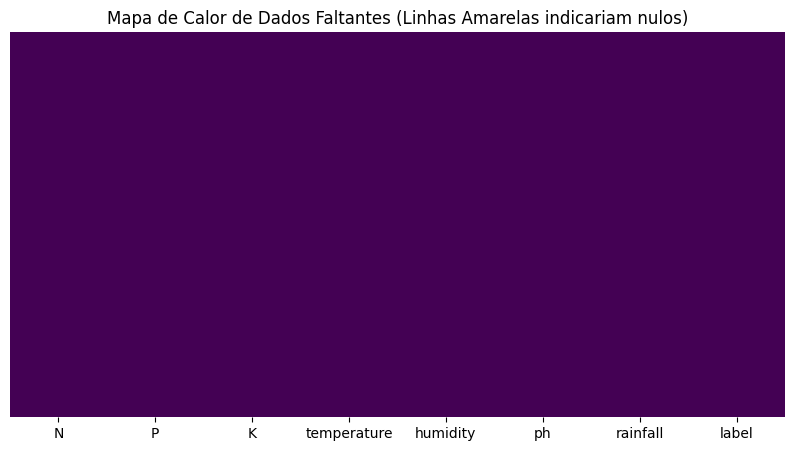

In [20]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_crop.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Dados Faltantes (Linhas Amarelas indicariam nulos)')
plt.show()

### 3. Distribuição das Variáveis de Solo e Clima
Vamos plotar histogramas com curvas de densidade (KDE) para cada uma das características contínuas (Nitrogênio, Fósforo, Potássio, Temperatura, Umidade, pH e Chuva) para avaliar assimetria e presença de outliers.

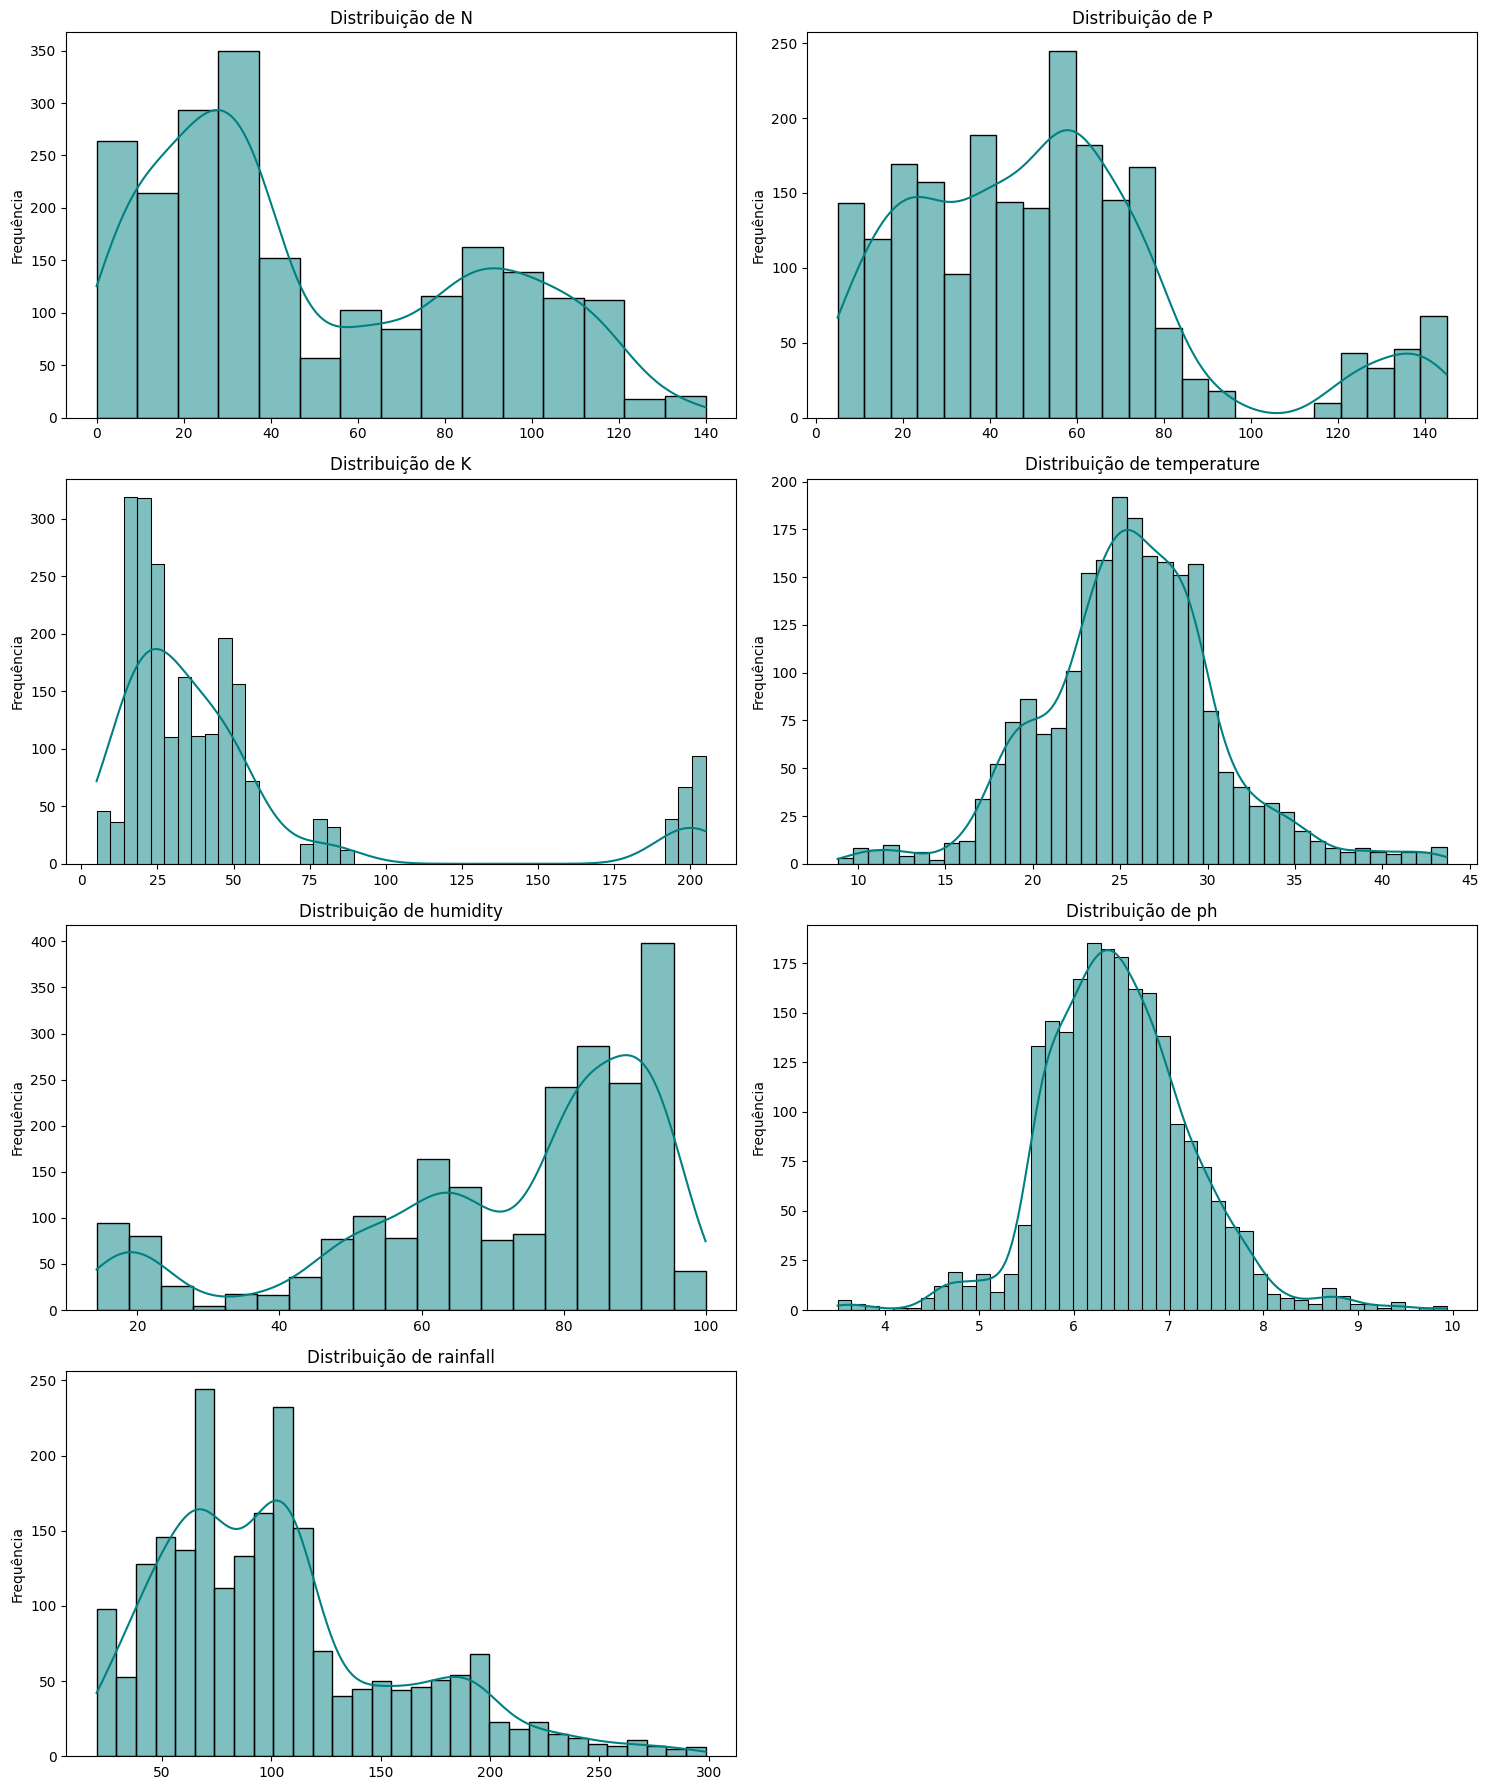

In [21]:
# Seleciona colunas numéricas
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Define o grid de gráficos
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 18))
axes = axes.flatten() # Achata a matriz de eixos para fácil iteração

for i, col in enumerate(features):
    sns.histplot(df_crop[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')

# Remove o último eixo sobressalente
if len(features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 4. Frequência das Classes (Variável Alvo)
Por fim, verificamos visualmente se o dataset está balanceado em relação às diferentes culturas recomendadas.

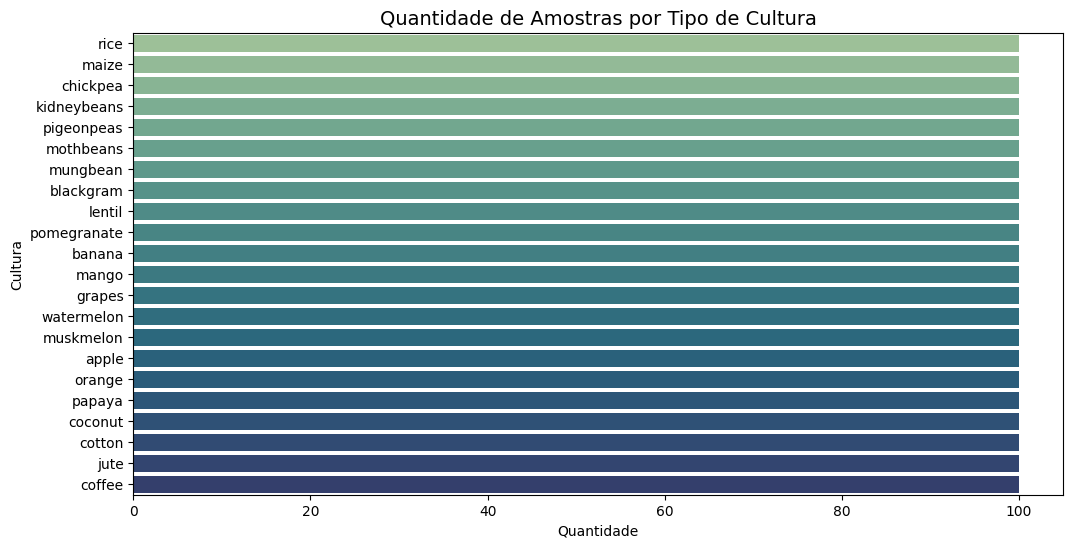

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_crop, y='label', order=df_crop['label'].value_counts().index, palette='crest')
plt.title('Quantidade de Amostras por Tipo de Cultura', fontsize=14)
plt.xlabel('Quantidade')
plt.ylabel('Cultura')
plt.show()

### 5. Matriz de Correlação das Variáveis Numéricas
Vamos analisar como as variáveis numéricas de solo e clima se relacionam entre si utilizando o coeficiente de correlação de Pearson e visualizando-o em um mapa de calor.

--- Matriz de Correlação ---


,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


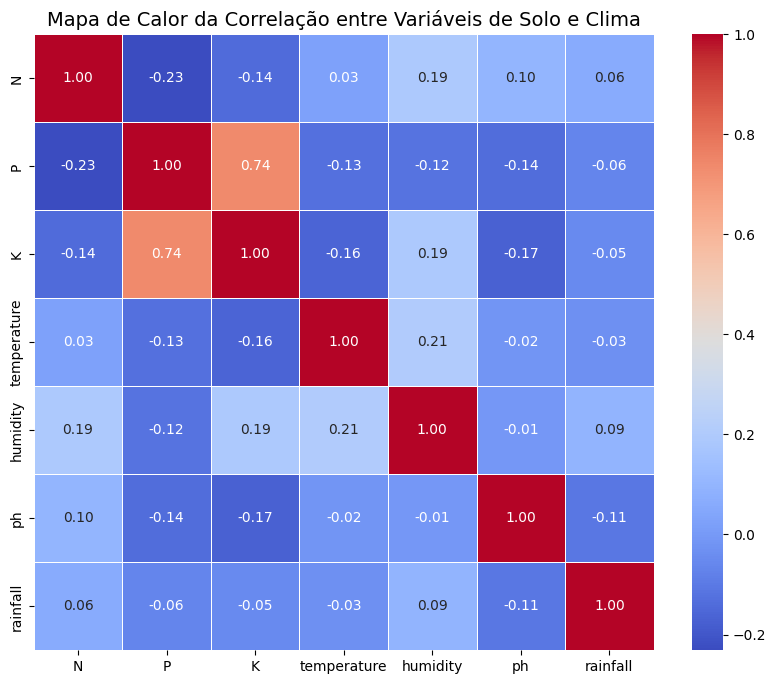

In [23]:
# Seleciona apenas as colunas numéricas para calcular a correlação
colunas_numericas = df_crop.select_dtypes(include=[np.number])
corr_matrix = colunas_numericas.corr()

# Exibe a matriz de correlação em formato tabular
print("--- Matriz de Correlação ---")
display(corr_matrix)

# Plota o Heatmap da correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor da Correlação entre Variáveis de Solo e Clima', fontsize=14)
plt.show()

O coeficiente de correlação varia de -1 a 1:

Próximo de 1: Correlação positiva forte (quando uma variável sobe, a outra também sobe).
Próximo de -1: Correlação negativa forte (quando uma variável sobe, a outra desce).
Próximo de 0: Pouca ou nenhuma relação linear entre as variáveis.
1. Correlação Forte em Destaque
Fósforo (P) e Potássio (K) possuem correlação positiva muito forte (0.74): Este é o relacionamento mais forte no dataset. Isso significa que solos ricos em Fósforo também tendem a ser muito ricos em Potássio nesta base de dados. Agronomicamente, isso é comum porque certos fertilizantes (como os do tipo NPK) aplicam ambos em conjunto, ou porque determinadas culturas exigem altos níveis de ambos os nutrientes simultaneamente (como uva e maçã).
2. Correlações Fracas a Moderadas (Relações Sutis)
Temperatura e Umidade (0.21): Existe uma leve tendência de que áreas com temperaturas ligeiramente mais altas também registrem maior umidade neste conjunto de dados.
Nitrogênio (N) e Potássio (K) (-0.14) / Nitrogênio (N) e Fósforo (P) (-0.23): Há uma correlação negativa bem sutil aqui. Significa que, de forma geral, quando há muito Nitrogênio no solo, os níveis de Fósforo e Potássio tendem a ser ligeiramente menores (ou vice-versa).
3. Ausência de Correlação (Variáveis Independentes)
pH e Chuva (-0.11) / pH e Temperatura (-0.02): Próximos de zero, o que mostra que a acidez do solo (pH) não possui uma relação linear direta com a temperatura ou a quantidade de chuva recebida.
Chuva e Nitrogênio (0.06): Praticamente nula, indicando que o nível de nitrogênio medido no solo não varia linearmente com o volume de chuva.
O que isso significa para os seus modelos de Machine Learning?
Como a grande maioria das variáveis tem correlação muito próxima de zero entre si (com exceção de P e K), isso indica que quase todas as características trazem informações únicas e independentes para o dataset. Isso é excelente para modelos preditivos, pois reduz problemas de multicolinearidade!

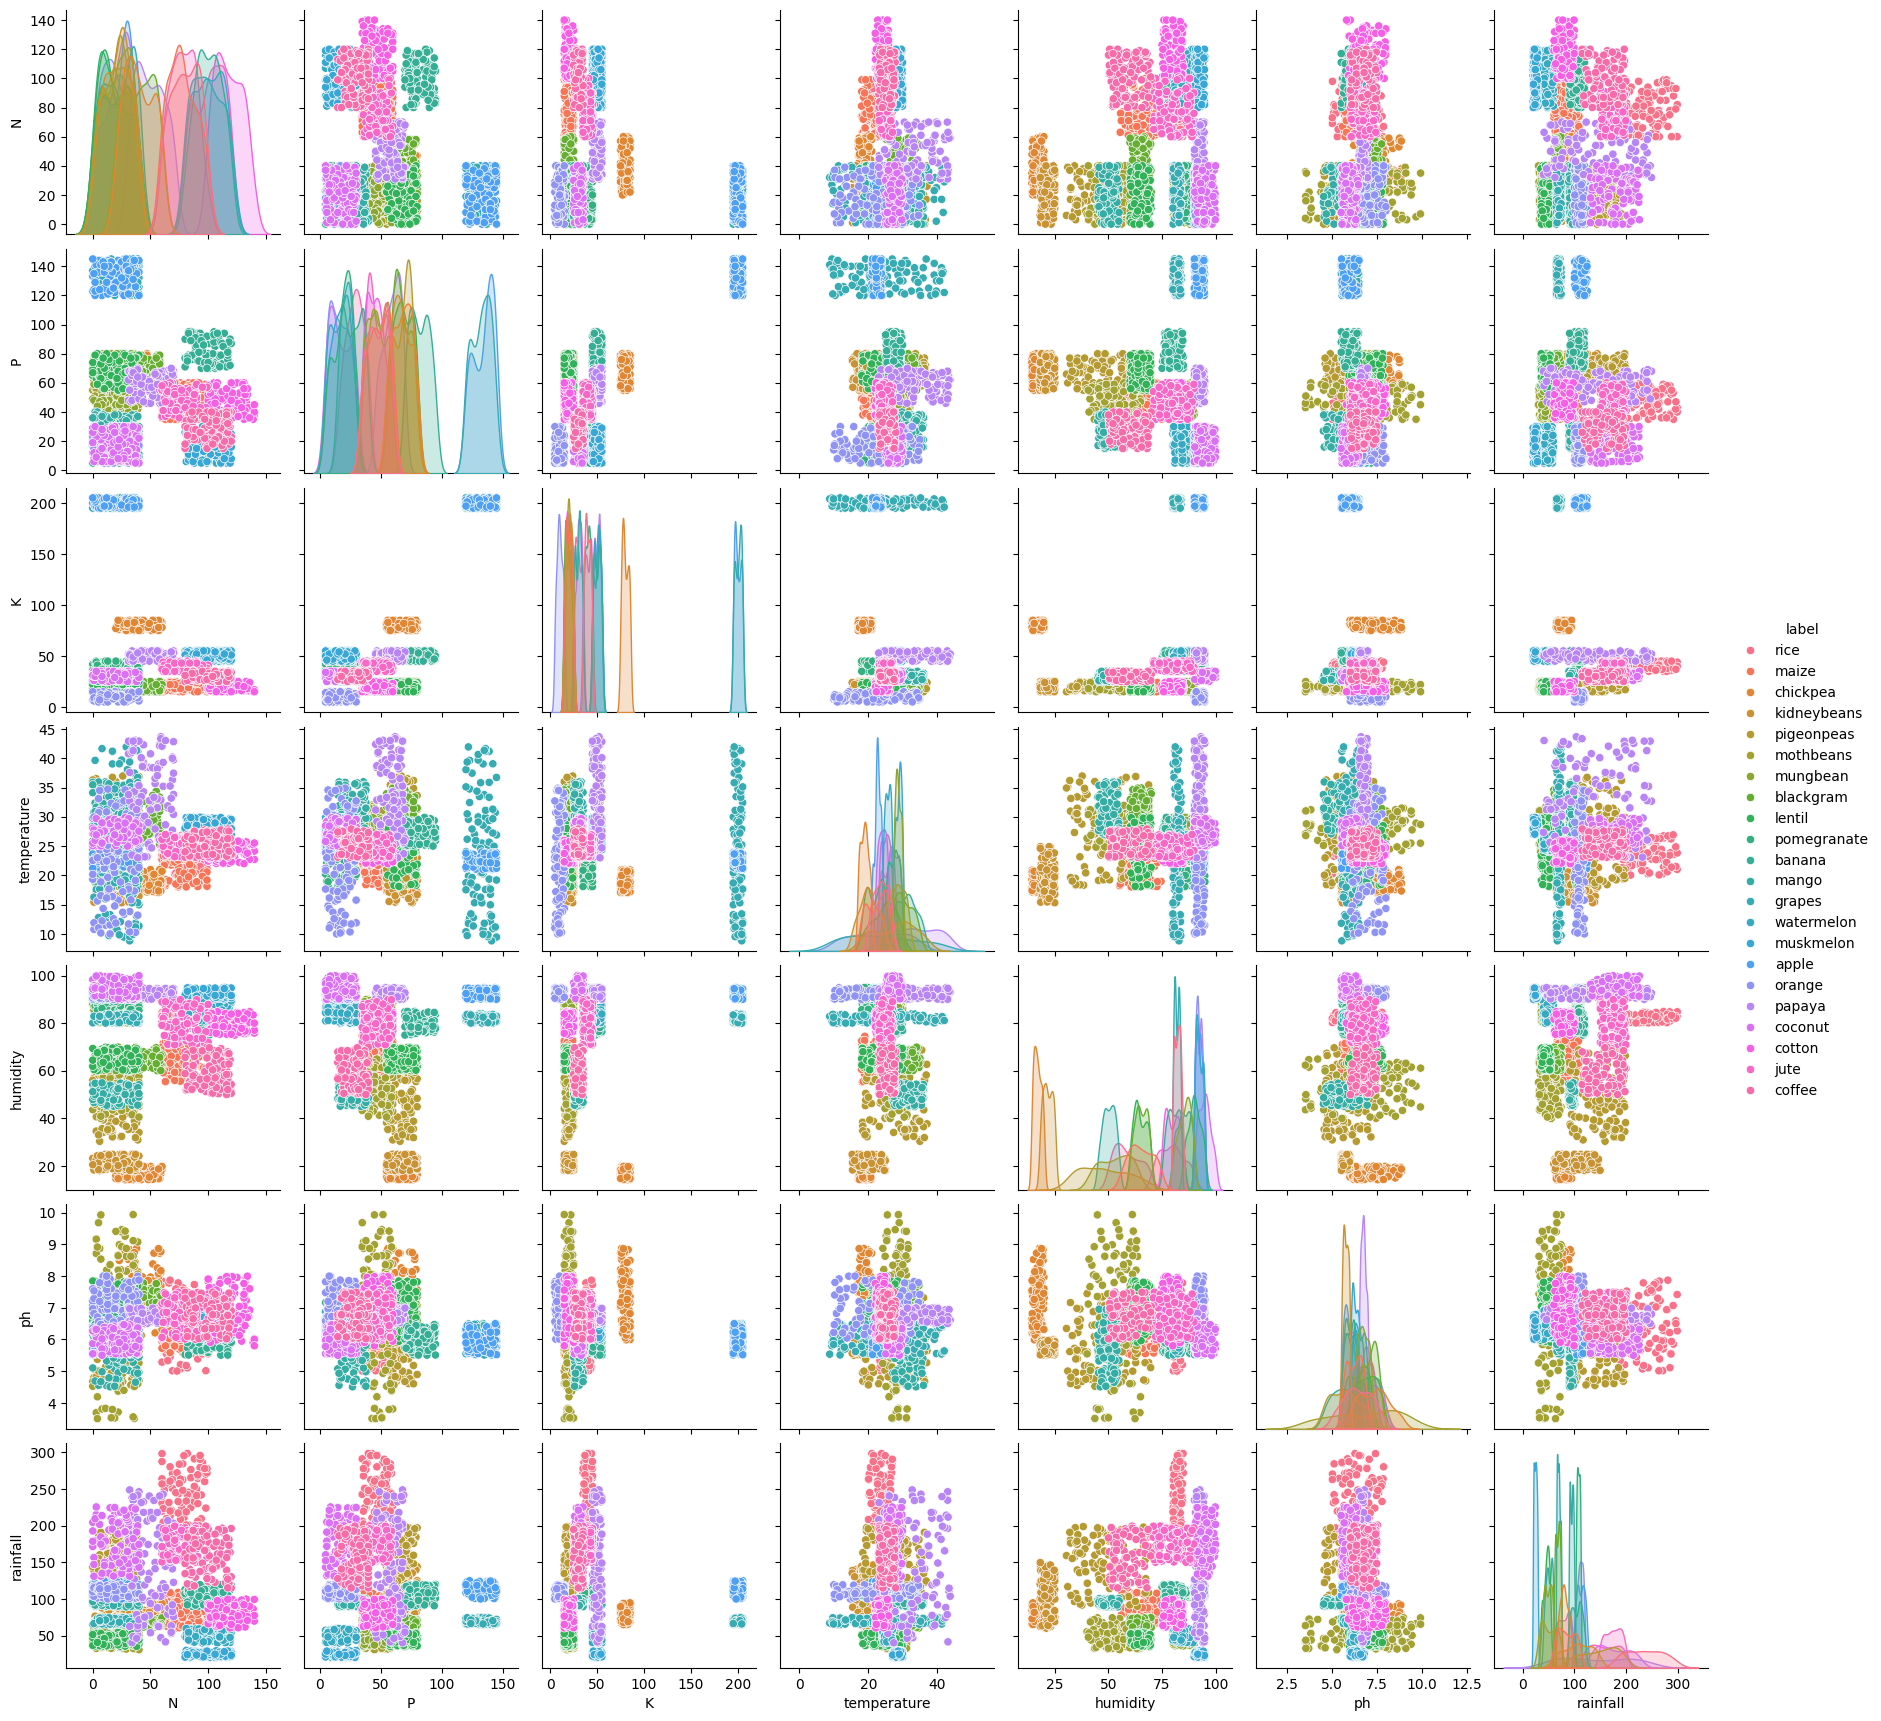

In [6]:
sns.pairplot(df_crop, hue = 'label')

### 6. Equações das Retas de Regressão Linear
Para quantificar a inclinação e a relação linear entre os pares de variáveis, vamos calcular os parâmetros da equação da reta ($y = ax + b$) para cada combinação de variáveis utilizando a biblioteca `scipy.stats` ou `statsmodels`.

In [7]:
from scipy import stats

# Vamos listar as variáveis numéricas
variaveis = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

print("--- Equações de Regressão Linear (y = ax + b) para pares com maior correlação ---\n")

# Para evitar poluição, vamos calcular para todas as combinações únicas e ordenar pelo R² (coeficiente de determinação)
resultados = []

for i in range(len(variaveis)):
    for j in range(i + 1, len(variaveis)):
        x_var = variaveis[i]
        y_var = variaveis[j]

        # Calcula a regressão linear simples
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_crop[x_var], df_crop[y_var])
        r_squared = r_value ** 2

        resultados.append({
            'Par': f"{y_var} vs {x_var}",
            'Equação': f"{y_var} = {slope:.4f} * {x_var} + ({intercept:.4f})",
            'R2': r_squared,
            'p-value': p_value
        })

# Ordena os resultados pelo R² de forma decrescente
df_regressoes = pd.DataFrame(resultados).sort_values(by='R2', ascending=False)

display(df_regressoes)

--- Equações de Regressão Linear (y = ax + b) para pares com maior correlação ---



,Par,Equação,R2,p-value
6,K vs P,K = 1.1304 * P + (-12.1744),0.542038,0.000000e+00
0,P vs N,P = -0.2068 * N + (63.8174),0.053574,3.823471e-28
15,humidity vs temperature,humidity = 0.9027 * temperature + (48.3572),0.042156,2.274853e-22
12,humidity vs K,humidity = 0.0839 * K + (67.4422),0.036427,1.714900e-19
3,humidity vs N,humidity = 0.1150 * N + (65.6684),0.036362,1.848573e-19
13,ph vs K,ph = -0.0026 * K + (6.5942),0.028731,1.205751e-15
11,temperature vs K,temperature = -0.0160 * K + (26.3883),0.025724,3.802198e-14
1,K vs N,K = -0.1928 * N + (57.8941),0.019744,3.599057e-11
9,ph vs P,ph = -0.0032 * P + (6.6423),0.019049,7.972631e-11
7,temperature vs P,temperature = -0.0196 * P + (26.6610),0.016267,1.932983e-09


### 7. Visualização Gráfica das Retas de Regressão
Vamos gerar gráficos de dispersão combinados com a linha de regressão linear ajustada para cada um dos pares de variáveis físicas e químicas analisados anteriormente.

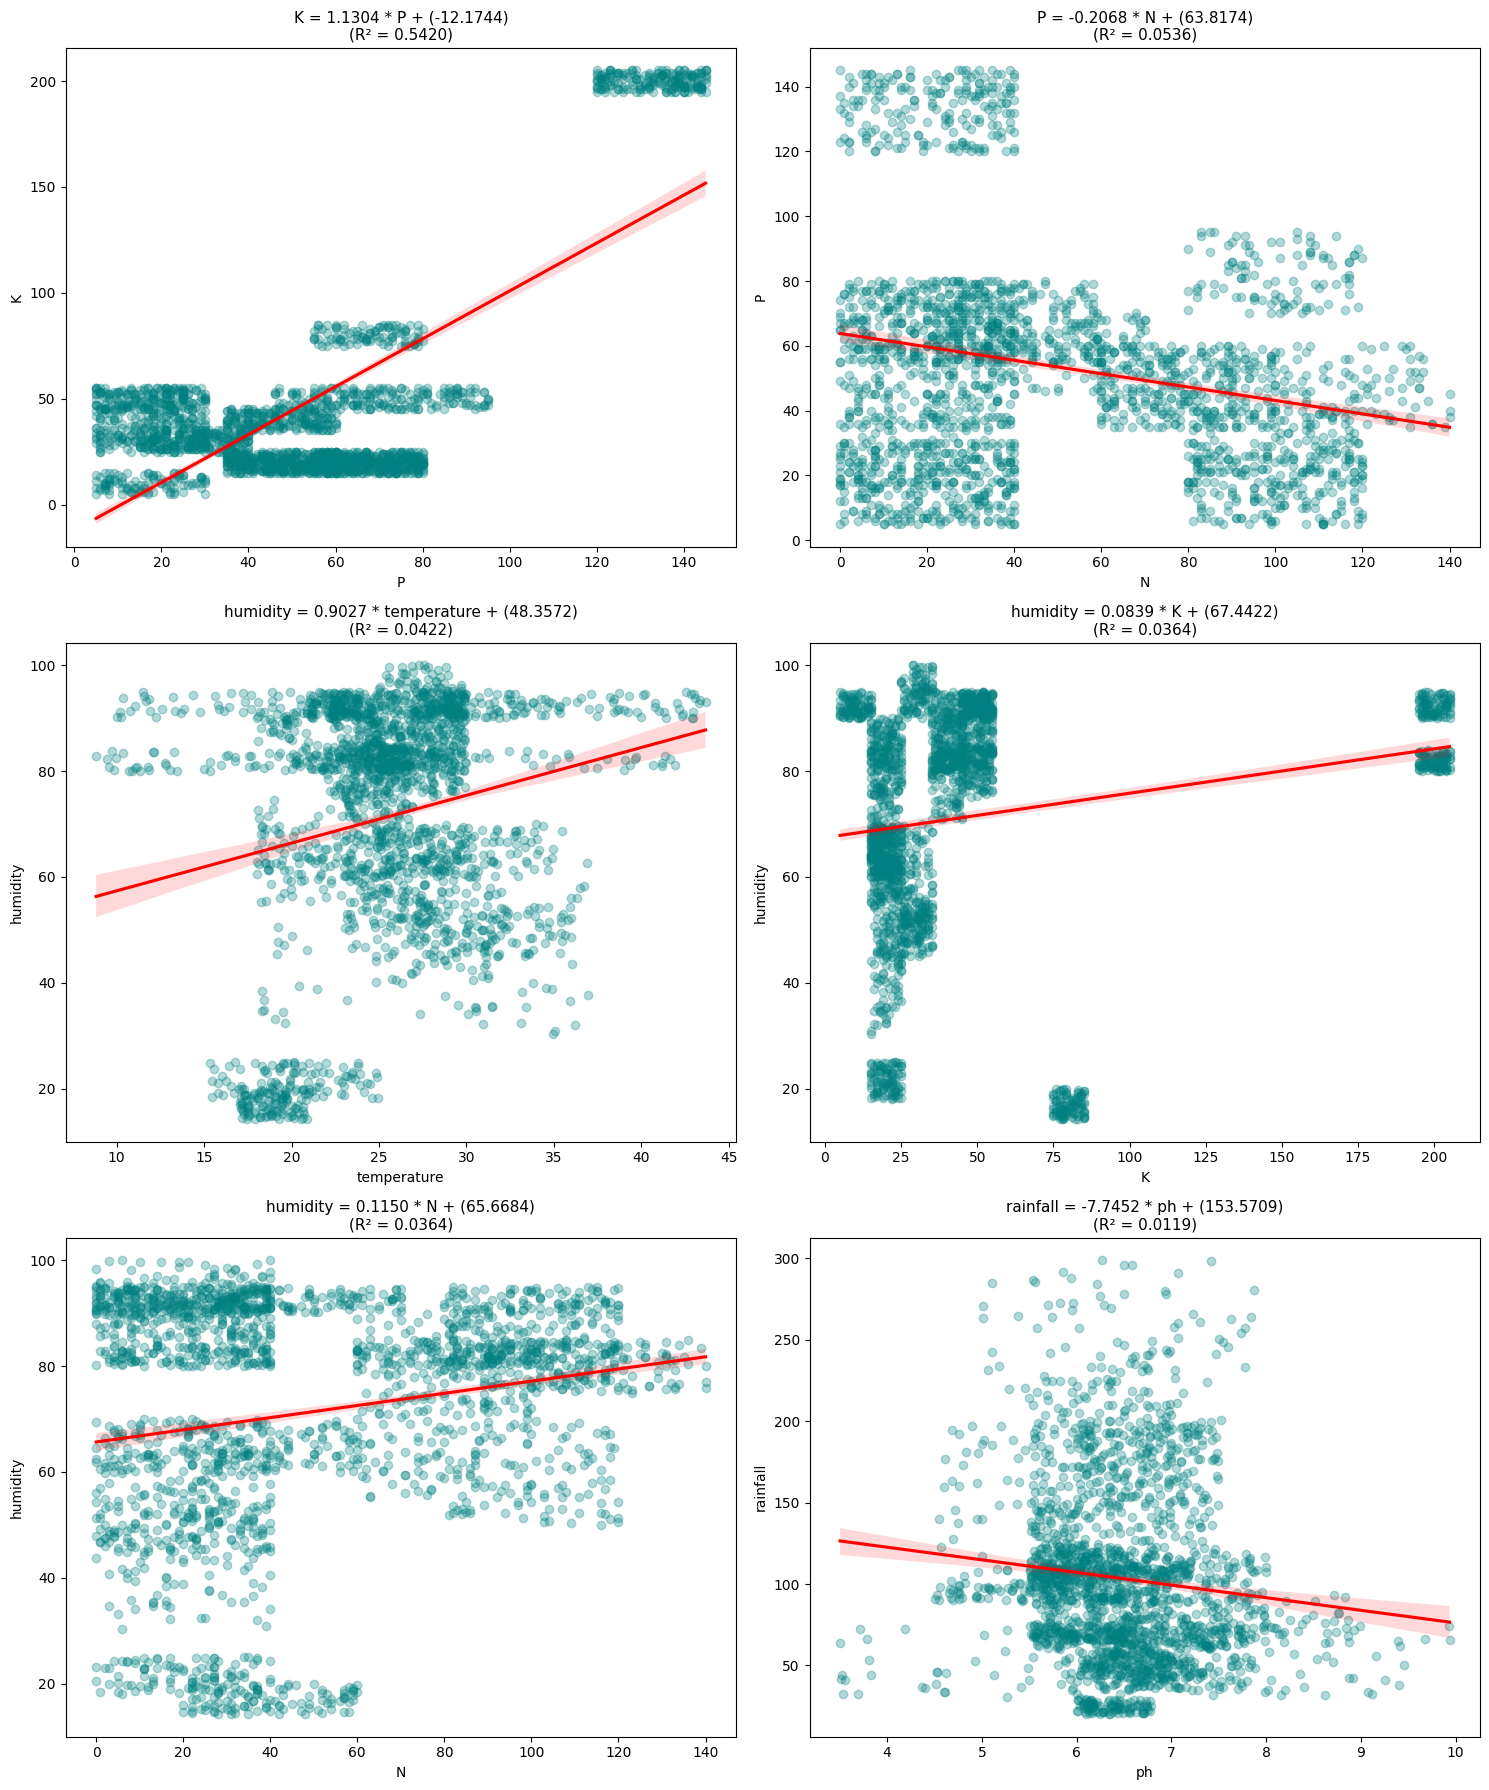

In [8]:
# Definindo as variáveis para o plot das regressões
pares_importantes = [
    ('P', 'K'),
    ('N', 'P'),
    ('temperature', 'humidity'),
    ('K', 'humidity'),
    ('N', 'humidity'),
    ('ph', 'rainfall')
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for idx, (x_col, y_col) in enumerate(pares_importantes):
    # Obtém os coeficientes calculados anteriormente para exibir no título
    linha = df_regressoes[df_regressoes['Par'] == f"{y_col} vs {x_col}"].iloc[0]
    eq = linha['Equação']
    r2 = linha['R2']

    # Plota a dispersão e a reta de regressão ajustada
    sns.regplot(data=df_crop, x=x_col, y=y_col, ax=axes[idx],
                color='darkblue', scatter_kws={'alpha':0.3, 'color': 'teal'}, line_kws={'color':'red'})

    axes[idx].set_title(f"{eq}\n(R² = {r2:.4f})", fontsize=11)
    axes[idx].set_xlabel(x_col)
    axes[idx].set_ylabel(y_col)

plt.tight_layout()
plt.show()